# Core Benchmark Analysis

Notebook ini dipakai untuk membaca hasil dari pipeline benchmark inti yang sudah dikunci:

- `dice`
- `ocean`
- `ft`
- `nn`

Notebook ini **tidak** menjalankan logika eksperimen utama. Source of truth tetap berada di scripts/configs/results pipeline `experiments/`.


## Workflow

1. Jalankan benchmark inti lewat:

```powershell
.\\.venv\\Scripts\\python.exe experiments\\scripts\\run_core_checkpoint.py `
  --scenario-limit 10 `
  --stability-limit 10 `
  --repeat-count 5 `
  --scenario-timeout-seconds 180 `
  --stability-timeout-seconds 180
```

2. Notebook ini akan membaca `experiments/results/latest/comparison.txt`.
3. Jika ingin membaca run lama, isi `MANUAL_COMPARISON_ROOT` di sel konfigurasi.


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)


In [3]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Tidak menemukan repo root yang berisi pyproject.toml")


REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = REPO_ROOT / "experiments" / "results"
LATEST_POINTER = RESULTS_ROOT / "latest" / "comparison.txt"

# Isi manual jika ingin membuka comparison tertentu.
MANUAL_COMPARISON_ROOT = None

if MANUAL_COMPARISON_ROOT:
    COMPARISON_ROOT = REPO_ROOT / MANUAL_COMPARISON_ROOT
else:
    latest_relative = LATEST_POINTER.read_text(encoding="utf-8").strip()
    COMPARISON_ROOT = REPO_ROOT / latest_relative

COMPARISON_ROOT


WindowsPath('D:/Perkuliahan/Tugas Akhir - The Last Chapter/Program/diabetify-cf/experiments/results/comparisons/20260505_065458')

In [4]:
CHECKPOINT_REPORT_PATH = COMPARISON_ROOT / "checkpoint_report.md"
COMPARISON_REPORT_PATH = COMPARISON_ROOT / "comparison_report.md"
SCOPE_MANIFEST_PATH = COMPARISON_ROOT / "core_benchmark_scope.json"
COMBINED_DIR = COMPARISON_ROOT / "combined"

SCENARIO_SUMMARY_PATH = COMBINED_DIR / "scenario_summary.csv"
STABILITY_SUMMARY_PATH = COMBINED_DIR / "stability_summary.csv"
CANDIDATES_PATH = COMBINED_DIR / "candidates.csv"
INPUTS_PATH = COMBINED_DIR / "inputs.csv"

paths = {
    "checkpoint_report": CHECKPOINT_REPORT_PATH,
    "comparison_report": COMPARISON_REPORT_PATH,
    "scope_manifest": SCOPE_MANIFEST_PATH,
    "scenario_summary": SCENARIO_SUMMARY_PATH,
    "stability_summary": STABILITY_SUMMARY_PATH,
    "candidates": CANDIDATES_PATH,
    "inputs": INPUTS_PATH,
}

pd.DataFrame(
    [{"name": key, "path": str(path.relative_to(REPO_ROOT)), "exists": path.exists()} for key, path in paths.items()]
)


,name,path,exists
0,checkpoint_report,experiments\results\comparisons\20260505_065458\checkpoint_report.md,True
1,comparison_report,experiments\results\comparisons\20260505_065458\comparison_report.md,True
2,scope_manifest,experiments\results\comparisons\20260505_065458\core_benchmark_scope.json,True
3,scenario_summary,experiments\results\comparisons\20260505_065458\combined\scenario_summary.csv,True
4,stability_summary,experiments\results\comparisons\20260505_065458\combined\stability_summary.csv,True
5,candidates,experiments\results\comparisons\20260505_065458\combined\candidates.csv,True
6,inputs,experiments\results\comparisons\20260505_065458\combined\inputs.csv,True


In [5]:
display(Markdown(CHECKPOINT_REPORT_PATH.read_text(encoding="utf-8")))
display(Markdown(COMPARISON_REPORT_PATH.read_text(encoding="utf-8")))

if SCOPE_MANIFEST_PATH.exists():
    scope_manifest = json.loads(SCOPE_MANIFEST_PATH.read_text(encoding="utf-8"))
    display(pd.DataFrame(scope_manifest.get("core_engines", [])))
    display(pd.DataFrame(scope_manifest.get("excluded_candidates", [])))


# Experiment Checkpoint

- Status: `PASS`
- Comparison root: `D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458`
- Observed engines: dice, ft, nn, ocean
- Rows: scenario=24, stability=4, candidates=197

## Scenario Summary

| Engine | Scenarios | Completed | Timeout | Failed | Mean feasible | Max violation |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| dice | 6 | 3 | 3 | 0 | 33.3% | 0.0000 |
| ft | 6 | 6 | 0 | 0 | 25.0% | 0.0000 |
| nn | 6 | 6 | 0 | 0 | 45.0% | 0.0000 |
| ocean | 6 | 6 | 0 | 0 | 28.3% | 0.0000 |

## Stability Summary

| Engine | Cases | Mean feasible | Evaluable | Feasible-only Jaccard |
| --- | ---: | ---: | ---: | ---: |
| dice | 10 | 100.0% | 100.0% | 0.9500 |
| ft | 10 | 40.0% | 40.0% | 1.0000 |
| nn | 10 | 100.0% | 100.0% | 1.0000 |
| ocean | 10 | 70.0% | 80.0% | 1.0000 |

## Warnings

- dice/bmi_only timed out.
- dice/activity_only timed out.
- dice/tight_bounds timed out.

## Files

- `comparison_report.md`
- `comparison_manifest.json`
- `audit_report.json`
- `checkpoint_report.md`
- `combined/scenario_summary.csv`
- `combined/stability_summary.csv`
- `combined/inputs.csv`
- `combined/candidates.csv`


# Comparison Report

- Comparison root: `D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458`
- Scenario rows: 24
- Stability rows: 4
- Candidate rows: 197

## Engine Summary

| Engine | Scenarios | Completed | Timeout | Failed | Mean feasible | Candidate rows |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| dice | 6 | 3 | 3 | 0 | 33.3% | 56 |
| ft | 6 | 6 | 0 | 0 | 25.0% | 45 |
| nn | 6 | 6 | 0 | 0 | 45.0% | 79 |
| ocean | 6 | 6 | 0 | 0 | 28.3% | 17 |

## Scenario Matrix

| Engine | Scenario | Status | Feasible | Target | Runtime ms | Step runtime s | Reason counts |
| --- | --- | --- | ---: | ---: | ---: | ---: | --- |
| dice | all_mutable | completed | 100.0% | 100.0% | 321.1000 | 8.0930 | {"OK": 10} |
| dice | lifestyle_combo | completed | 100.0% | 100.0% | 298.9000 | 5.6870 | {"OK": 10} |
| dice | bmi_only | timeout | 0.0% | 0.0% | 0.0000 | 180.0470 | {"timeout": 1} |
| dice | activity_only | timeout | 0.0% | 0.0% | 0.0000 | 180.0310 | {"timeout": 1} |
| dice | tight_bounds | timeout | 0.0% | 0.0% | 0.0000 | 180.0320 | {"timeout": 1} |
| dice | no_mutable | completed | 0.0% | 0.0% | 4.1000 | 2.7810 | {"NO_MUTABLE_FEATURE": 10} |
| ft | all_mutable | completed | 40.0% | 100.0% | 85.1000 | 3.5630 | {"TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 6, "OK": 4} |
| ft | lifestyle_combo | completed | 40.0% | 100.0% | 82.2000 | 3.5000 | {"TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 6, "OK": 4} |
| ft | bmi_only | completed | 70.0% | 100.0% | 615.2000 | 8.8130 | {"OK": 7, "TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 2, "MEDICAL_RULE_VIOLATION_ONLY": 1} |
| ft | activity_only | completed | 0.0% | 0.0% | 25.7000 | 2.9840 | {"TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 10} |
| ft | tight_bounds | completed | 0.0% | 0.0% | 280.7000 | 5.5150 | {"TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 5, "MEDICAL_RULE_VIOLATION_ONLY": 5} |
| ft | no_mutable | completed | 0.0% | 0.0% | 4.1000 | 2.7500 | {"NO_MUTABLE_FEATURE": 10} |
| nn | all_mutable | completed | 100.0% | 100.0% | 496.0000 | 7.6880 | {"OK": 10} |
| nn | lifestyle_combo | completed | 100.0% | 100.0% | 371.6000 | 6.4220 | {"OK": 10} |
| nn | bmi_only | completed | 70.0% | 100.0% | 270.0000 | 5.3590 | {"OK": 7, "TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 3} |
| nn | activity_only | completed | 0.0% | 0.0% | 48.2000 | 3.1720 | {"MEDICAL_RULE_VIOLATION_ONLY": 6, "TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 4} |
| nn | tight_bounds | completed | 0.0% | 0.0% | 48.4000 | 3.2660 | {"TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 10} |
| nn | no_mutable | completed | 0.0% | 0.0% | 4.0000 | 2.6880 | {"NO_MUTABLE_FEATURE": 10} |
| ocean | all_mutable | completed | 70.0% | 100.0% | 3303.9000 | 37.0940 | {"OK": 7, "TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 2, "MEDICAL_RULE_VIOLATION_ONLY": 1} |
| ocean | lifestyle_combo | completed | 70.0% | 100.0% | 3198.3000 | 34.8750 | {"OK": 7, "TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 2, "MEDICAL_RULE_VIOLATION_ONLY": 1} |
| ocean | bmi_only | completed | 30.0% | 100.0% | 3188.8000 | 34.8750 | {"TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 7, "OK": 3} |
| ocean | activity_only | completed | 0.0% | 0.0% | 2638.9000 | 29.3440 | {"TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 10} |
| ocean | tight_bounds | completed | 0.0% | 0.0% | 3178.8000 | 34.7040 | {"TARGET_UNREACHABLE_UNDER_CONSTRAINTS": 10} |
| ocean | no_mutable | completed | 0.0% | 0.0% | 5.3000 | 3.4380 | {"NO_MUTABLE_FEATURE": 10} |

## Stability

| Engine | Case count | Mean feasible | Fully feasible cases | Stability evaluable cases | Feasible-only Jaccard | Feasible-only std norm | All-repeat Jaccard |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| dice | 10 | 100.0% | 100.0% | 100.0% | 0.9500 | 0.0228 | 0.9500 |
| ft | 10 | 40.0% | 40.0% | 40.0% | 1.0000 | 0.0000 | 1.0000 |
| nn | 10 | 100.0% | 100.0% | 100.0% | 1.0000 | 0.0000 | 1.0000 |
| ocean | 10 | 70.0% | 50.0% | 80.0% | 1.0000 | 0.0000 | 0.8000 |

## Top Changed Features

### dice

| Feature | Count |
| --- | ---: |
| BMI | 56 |
| smoking_status | 24 |
| brinkman_index | 14 |
| moderate_physical_activity_frequency | 5 |
| is_hypertension | 4 |

### ft

| Feature | Count |
| --- | ---: |
| BMI | 38 |
| is_hypertension | 12 |
| smoking_status | 7 |
| brinkman_index | 5 |

### nn

| Feature | Count |
| --- | ---: |
| BMI | 76 |
| brinkman_index | 21 |
| smoking_status | 11 |
| moderate_physical_activity_frequency | 6 |
| is_hypertension | 5 |

### ocean

| Feature | Count |
| --- | ---: |
| BMI | 15 |
| smoking_status | 8 |
| brinkman_index | 2 |


## Design Notes

- Engine comparison uses the same scenario configs, limits, repeat count, and timeouts.
- `completed` means the subprocess finished; success is measured by feasible rate and violations.
- Feasible-only stability is computed only from repeats that produced FEASIBLE counterfactuals.
- Small limits are smoke-level evidence. Increase limits before drawing final research claims.

## Important Files

- `comparison_manifest.json`
- `comparison_report.md`
- `combined/scenario_summary.csv`
- `combined/stability_summary.csv`
- `combined/inputs.csv`
- `combined/candidates.csv`
- `baselines/<engine>/<timestamp>/report.md`


,engine,config_path,category,notes
0,dice,experiments/configs/engines/dice.json,external_library,General-purpose counterfactual library integrated natively in the main environment.
1,ocean,experiments/configs/engines/ocean.json,external_library,Tree-ensemble optimization method compatible with the main XGBoost model.
2,ft,experiments/configs/engines/ft.json,custom_baseline,FeatureTweak-inspired tree-threshold search baseline implemented for the main pipeline.
3,nn,experiments/configs/engines/nn.json,custom_baseline,Nearest-neighbor projection baseline implemented for the main pipeline.


,engine,status,reason
0,dace,experimental_not_ready,Current adapter relies on a random-forest surrogate and does not yet produce usable feasible candidates.
1,carla,audited_not_integrated,Official stack is tied to legacy Python and package versions that are incompatible with the main environment.
2,focus,audited_not_integrated,Official implementation requires a legacy software stack and solver dependencies that are not suitable for the main environment.
3,oae,audited_not_integrated,Available implementation targets scikit-learn random forest rather than the native XGBoost model.
4,mace,audited_not_integrated,Available implementation targets legacy scikit-learn model families rather than the native XGBoost model.


In [6]:
scenario_df = pd.read_csv(SCENARIO_SUMMARY_PATH) if SCENARIO_SUMMARY_PATH.exists() else pd.DataFrame()
stability_df = pd.read_csv(STABILITY_SUMMARY_PATH) if STABILITY_SUMMARY_PATH.exists() else pd.DataFrame()
candidates_df = pd.read_csv(CANDIDATES_PATH) if CANDIDATES_PATH.exists() else pd.DataFrame()
inputs_df = pd.read_csv(INPUTS_PATH) if INPUTS_PATH.exists() else pd.DataFrame()

for name, frame in {
    "scenario": scenario_df,
    "stability": stability_df,
    "candidates": candidates_df,
    "inputs": inputs_df,
}.items():
    print(f"[{name}] shape={frame.shape}")
    if not frame.empty:
        print(list(frame.columns))
        print()


[scenario] shape=(24, 23)
['source_file', 'scenario', 'run_dir', 'total_cases', 'feasible_cases', 'feasible_rate', 'mean_runtime_ms', 'mean_candidate_count', 'candidate_rows', 'target_success_rate', 'plausibility_pass_rate', 'immutable_violation_rate', 'mutable_violation_rate', 'bounds_violation_rate', 'directional_violation_rate', 'mean_lof_score', 'mean_distance_l1', 'mean_changed_feature_count', 'status_counts', 'reason_counts', 'step_status', 'step_reason', 'step_runtime_seconds']

[stability] shape=(4, 11)
['source_file', 'case_count', 'mean_feasible_rate', 'fully_feasible_case_count', 'fully_feasible_case_rate', 'stability_evaluable_case_count', 'stability_evaluable_case_rate', 'mean_jaccard_changed_features', 'mean_stability_std_norm', 'mean_feasible_only_jaccard_changed_features', 'mean_feasible_only_stability_std_norm']

[candidates] shape=(197, 17)
['source_file', 'engine_name', 'request_id', 'candidate_id', 'status', 'probability_low_risk', 'distance_l1', 'changed_feature_co

In [7]:
def pick_column(frame: pd.DataFrame, candidates: list[str]) -> str | None:
    for name in candidates:
        if name in frame.columns:
            return name
    return None


scenario_engine_col = pick_column(scenario_df, ["engine_name", "engine"])
scenario_name_col = pick_column(scenario_df, ["scenario_name", "scenario"])
scenario_status_col = pick_column(scenario_df, ["status"])
scenario_feasible_col = pick_column(scenario_df, ["feasible_rate", "feasible"])
scenario_runtime_col = pick_column(scenario_df, ["mean_runtime_ms", "runtime_ms"])

stability_engine_col = pick_column(stability_df, ["engine_name", "engine"])
stability_feasible_col = pick_column(stability_df, ["mean_feasible_rate", "mean_feasible", "feasible_rate"])
stability_jaccard_col = pick_column(stability_df, ["mean_jaccard_changed_features", "feasible_only_jaccard", "all_repeat_jaccard"])

candidate_engine_col = pick_column(candidates_df, ["engine_name", "engine"])
candidate_distance_col = pick_column(candidates_df, ["distance_l1"])
candidate_changed_count_col = pick_column(candidates_df, ["changed_feature_count", "changed_feature_count_eval"])


## Scenario Overview

In [8]:
if scenario_df.empty:
    print("scenario_summary.csv belum tersedia")
else:
    summary_cols = [col for col in [scenario_engine_col, scenario_name_col, scenario_status_col, scenario_feasible_col, scenario_runtime_col] if col]
    display(scenario_df[summary_cols].sort_values(summary_cols[:2]))

    if scenario_engine_col and scenario_name_col and scenario_feasible_col:
        pivot = scenario_df.pivot(index=scenario_name_col, columns=scenario_engine_col, values=scenario_feasible_col)
        display(pivot)
        ax = pivot.plot(kind="bar", figsize=(12, 5))
        ax.set_title("Feasible Rate per Scenario")
        ax.set_ylabel("Feasible rate")
        ax.set_xlabel("Scenario")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    if scenario_engine_col and scenario_runtime_col:
        runtime_pivot = scenario_df.pivot(index=scenario_name_col, columns=scenario_engine_col, values=scenario_runtime_col)
        display(runtime_pivot)
        ax = runtime_pivot.plot(kind="bar", figsize=(12, 5))
        ax.set_title("Mean Runtime per Scenario (ms)")
        ax.set_ylabel("Runtime ms")
        ax.set_xlabel("Scenario")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()


,scenario,feasible_rate,mean_runtime_ms
3,activity_only,0.0,0.0
9,activity_only,0.0,25.7
15,activity_only,0.0,48.2
21,activity_only,0.0,2638.9
6,all_mutable,0.4,85.1
18,all_mutable,0.7,3303.9
0,all_mutable,1.0,321.1
12,all_mutable,1.0,496.0
2,bmi_only,0.0,0.0
20,bmi_only,0.3,3188.8


## Stability Overview

In [9]:
if stability_df.empty:
    print("stability_summary.csv belum tersedia")
else:
    display(stability_df)

    if stability_engine_col and stability_feasible_col:
        ax = stability_df.plot(
            x=stability_engine_col,
            y=stability_feasible_col,
            kind="bar",
            figsize=(8, 4),
            legend=False,
        )
        ax.set_title("Mean Feasible Rate on Stability Evaluation")
        ax.set_ylabel("Feasible rate")
        ax.set_xlabel("Engine")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    if stability_engine_col and stability_jaccard_col:
        ax = stability_df.plot(
            x=stability_engine_col,
            y=stability_jaccard_col,
            kind="bar",
            figsize=(8, 4),
            legend=False,
        )
        ax.set_title("Changed-Feature Consistency")
        ax.set_ylabel("Jaccard")
        ax.set_xlabel("Engine")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()


,source_file,case_count,mean_feasible_rate,fully_feasible_case_count,fully_feasible_case_rate,stability_evaluable_case_count,stability_evaluable_case_rate,mean_jaccard_changed_features,mean_stability_std_norm,mean_feasible_only_jaccard_changed_features,mean_feasible_only_stability_std_norm
0,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458\baselines\dice\20260505_065458\stability\stability\dice\20260505_070417\stability...,10,1.0,10,1.0,10,1.0,0.95,0.022799,0.95,0.022799
1,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458\baselines\ft\20260505_071017\stability\stability\ft\20260505_071047\stability_agg...,10,0.4,4,0.4,4,0.4,1.00,0.000000,1.00,0.000000
2,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458\baselines\nn\20260505_071052\stability\stability\nn\20260505_071123\stability_agg...,10,1.0,10,1.0,10,1.0,1.00,0.000000,1.00,0.000000
3,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458\baselines\ocean\20260505_070436\stability\stability\ocean\20260505_070734\stabili...,10,0.7,5,0.5,8,0.8,0.80,0.087015,1.00,0.000000


## Candidate-Level Overview

In [10]:
if candidates_df.empty:
    print("candidates.csv belum tersedia")
else:
    display(candidates_df.head())

    if candidate_engine_col and candidate_distance_col:
        distance_summary = (
            candidates_df.groupby(candidate_engine_col)[candidate_distance_col]
            .agg(["count", "mean", "median", "min", "max"])
            .sort_values("mean")
        )
        display(distance_summary)

    if candidate_engine_col and candidate_changed_count_col:
        changed_summary = (
            candidates_df.groupby(candidate_engine_col)[candidate_changed_count_col]
            .agg(["count", "mean", "median", "min", "max"])
            .sort_values("mean")
        )
        display(changed_summary)


,source_file,engine_name,request_id,candidate_id,status,probability_low_risk,distance_l1,changed_feature_count,lof_score,delta,target_success,immutable_violation_count,mutable_violation_count,bounds_violation_count,directional_violation_count,plausibility_pass,changed_feature_count_eval
0,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458\baselines\dice\20260505_065458\scenarios\all_mutable\benchmarks\dice\20260505_065...,dice,exp-00001,cf_1,FEASIBLE,0.579310,0.129519,2,1.019412,"{""BMI"": -8.28335, ""is_hypertension"": -1.0}",True,0,0,0,0,True,2
1,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458\baselines\dice\20260505_065458\scenarios\all_mutable\benchmarks\dice\20260505_065...,dice,exp-00001,cf_2,FEASIBLE,0.528983,0.160148,3,1.038323,"{""BMI"": -5.400015, ""brinkman_index"": -1.0, ""smoking_status"": -2.0}",True,0,0,0,0,True,3
2,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458\baselines\dice\20260505_065458\scenarios\all_mutable\benchmarks\dice\20260505_065...,dice,exp-00001,cf_3,FEASIBLE,0.582298,0.161060,3,1.029064,"{""BMI"": -5.810535, ""brinkman_index"": -1.0, ""smoking_status"": -2.0}",True,0,0,0,0,True,3
3,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458\baselines\dice\20260505_065458\scenarios\all_mutable\benchmarks\dice\20260505_065...,dice,exp-00002,cf_1,FEASIBLE,0.500466,0.003363,1,0.987066,"{""BMI"": -1.513195}",True,0,0,0,0,True,1
4,D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260505_065458\baselines\dice\20260505_065458\scenarios\all_mutable\benchmarks\dice\20260505_065...,dice,exp-00002,cf_2,FEASIBLE,0.502871,0.003736,1,0.985632,"{""BMI"": -1.681016}",True,0,0,0,0,True,1


,count,mean,median,min,max
engine_name,,,,,
nn,79,0.049743,0.015907,0.005268,0.279978
ft,45,0.053874,0.055556,0.002644,0.112605
ocean,17,0.056467,0.009989,0.002643,0.153230
dice,56,0.073495,0.057353,0.003363,0.166667


,count,mean,median,min,max
engine_name,,,,,
ft,45,1.377778,1.0,1,2
ocean,17,1.470588,1.0,1,3
nn,79,1.506329,1.0,1,4
dice,56,1.839286,2.0,1,3


,engine_name,feature,count
0,dice,BMI,56
4,dice,smoking_status,24
1,dice,brinkman_index,14
3,dice,moderate_physical_activity_frequency,5
2,dice,is_hypertension,4
5,ft,BMI,38
7,ft,is_hypertension,12
8,ft,smoking_status,7
6,ft,brinkman_index,5
9,nn,BMI,76


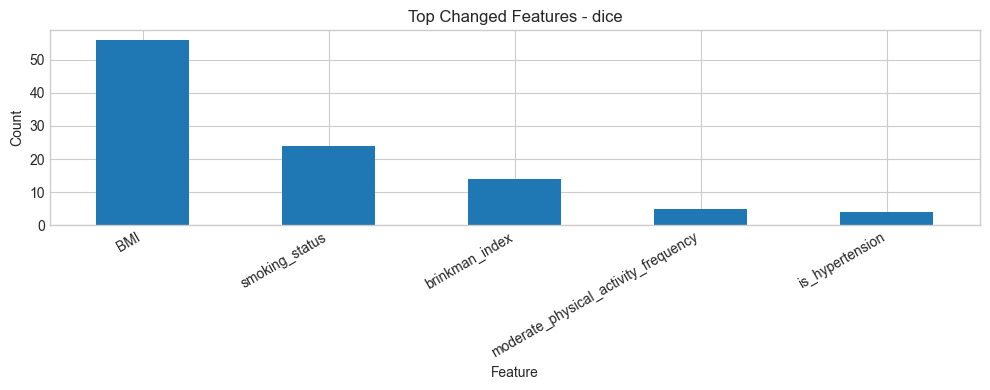

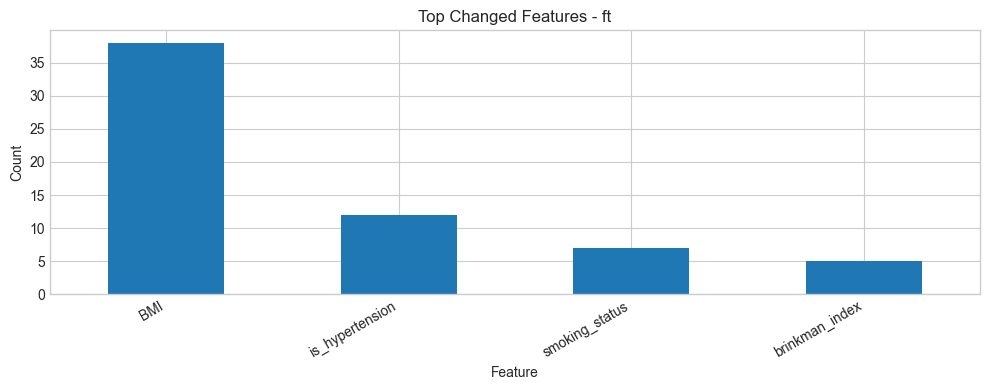

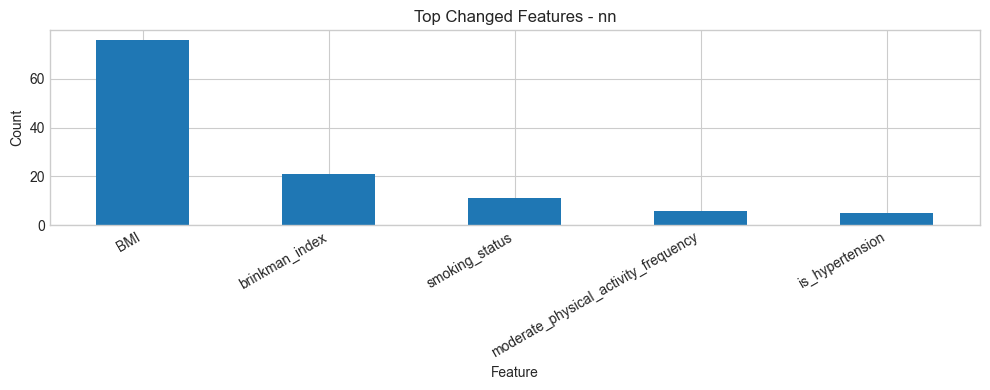

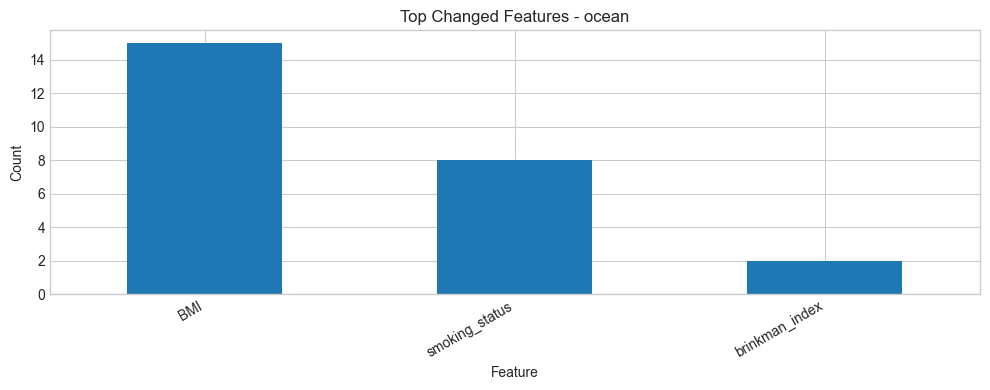

In [11]:
def top_changed_features(frame: pd.DataFrame, engine_column: str) -> pd.DataFrame:
    rows = []
    if "delta" not in frame.columns:
        return pd.DataFrame()
    for _, row in frame.iterrows():
        try:
            delta = json.loads(row["delta"])
        except Exception:
            continue
        for feature_name in delta.keys():
            rows.append({"engine_name": row[engine_column], "feature": feature_name})
    if not rows:
        return pd.DataFrame()
    exploded = pd.DataFrame(rows)
    return (
        exploded.groupby(["engine_name", "feature"])
        .size()
        .reset_index(name="count")
        .sort_values(["engine_name", "count", "feature"], ascending=[True, False, True])
    )


if not candidates_df.empty and candidate_engine_col:
    changed_features_df = top_changed_features(candidates_df, candidate_engine_col)
    display(changed_features_df)
    if not changed_features_df.empty:
        for engine_name, subset in changed_features_df.groupby("engine_name"):
            ax = subset.head(10).plot(
                x="feature",
                y="count",
                kind="bar",
                figsize=(10, 4),
                title=f"Top Changed Features - {engine_name}",
                legend=False,
            )
            ax.set_xlabel("Feature")
            ax.set_ylabel("Count")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()


## Analyst Notes

Catatan interpretasi yang biasanya perlu ditulis setelah melihat output:

- Engine mana yang paling feasible?
- Engine mana yang paling stabil?
- Tradeoff runtime vs feasible rate bagaimana?
- Pada scenario apa sebuah engine unggul atau gagal?
- Apakah baseline sederhana (`nn`) cukup kuat dibanding metode optimization/tree-specific?
- Apakah scenario `activity_only` dan `tight_bounds` tetap terlihat sebagai stress/unreachable scenario?
